# Storm Catalog Maps

Run this notebook after selecting a transposition domain with `mtools_01_domain_selection.ipynb`, creating the StormHub catalog, and checking the ranked-storm files with `mtools_02_storm_catalog_consistency.ipynb`.

Change the three paths and re-run on your
watershed / transposition domain / catalog.

Sections:
- Section 1 Setup and inputs
- Section 2 Max-pixel sanity flag and storms-per-year bar chart
- Section 3 Max-precip locations colored and sized by storm magnitude
- Section 4 Max-precip locations by season
- Section 5 Storm density heatmap
- Section 6 Precipitation distribution and ratio review

# Imports

In [1]:
import math
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as cx
import mapclassify
import matplotlib.font_manager as _fm


# Filepaths and Variables

In [6]:
# Target Watershed Domain
WATERSHED_PATH = Path("/workspaces/meteorology-tools/inputs/watershed/allegheny_huc.geojson")
# 24-hour SLAM-SIG Domains
SHP_24 = Path("/workspaces/meteorology-tools/inputs/transposition_domains/TD.AORC.0501.SLAM-SIG.2024.v1/TD.AORC.0501.SLAM-SIG.24hr.2024.v1.shp")
# 72-hour SLAM-SIG Domains
SHP_72 = Path("/workspaces/meteorology-tools/inputs/transposition_domains/TD.AORC.0501.SLAM-SIG.2024.v1/TD.AORC.0501.SLAM-SIG.72hr.2024.v1.shp")
# CONUS Boundary
SHP_CONUS = Path("/workspaces/meteorology-tools/inputs/conus/cb_2018_us_nation_20m/cb_2018_us_nation_20m.shp")
# Selected SLAM_SIG Transposition Domain from mtools_01_domain_selection.ipynb
SEL_TD_PATH = Path("/workspaces/meteorology-tools/outputs/01_domain_selection/SEL_SLAM-SIG-GSL0.100_EPSG5070.geojson")
# Geometrically Valid Transposition Domain Produced when Creating the Storm Catalog from Stormhub
VALID_TD_PATH = Path("/workspaces/meteorology-tools/inputs/storm_catalog/allegheny_storms/hydro_domains/allegheny-transpo-area-v01_valid.json")
# Determined Max Precipitation Locations Produced when Creating the Storm Catalog from Stormhub
MAX_PRECIP_PATH = Path("/workspaces/meteorology-tools/inputs/storm_catalog/max_precip_locations.geojson")
# Output directory to save figures and data products
OUT_DIR = Path("/workspaces/meteorology-tools/outputs/03_storm_catalog_maps")

SELECTED_GSL    = 0.100
WATERSHED_NAME  = 'Allegheny'
TD_NAME         = 'SLAM-SIG GSL=0.100 valid TD'
GEOG_CRS       = 'EPSG:4326'
EQUAL_AREA_CRS = 'EPSG:5070'
PLOT_CRS       = 'EPSG:3857'
OSM_BASEMAP_SOURCE = None # cx.providers.OpenStreetMap.Mapnik
OSM_BASEMAP_ZOOM = 6
MAX_PIXEL_FLAG = 30.0
PLOT_FONT_SIZE = 23
AORC_YEARS = 46

for p in [WATERSHED_PATH, SHP_24, SHP_72, SHP_CONUS, SEL_TD_PATH, VALID_TD_PATH, MAX_PRECIP_PATH]:
    assert p.exists(), p
print('inputs OK')
print('outputs ->', OUT_DIR)

inputs OK
outputs -> /workspaces/meteorology-tools/outputs/03_storm_catalog_maps


# Functions

In [7]:
def epsg5070_output_path(path):
    """Return the sibling path used for an EPSG:5070 converted copy."""
    p = Path(path)
    if 'EPSG5070' in p.stem.upper():
        return p
    return p.with_name(f'{p.stem}_EPSG5070{p.suffix}')


def _write_vector(gdf, path):
    path = Path(path)
    driver = 'ESRI Shapefile' if path.suffix.lower() == '.shp' else 'GeoJSON'
    gdf.to_file(path, driver=driver)


def ensure_epsg5070(path, label):
    """Load a vector file, convert to EPSG:5070 if needed, and return (path, GeoDataFrame)."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{label} not found: {path}')

    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f'{label} has no CRS metadata: {path}')

    if gdf.crs.to_epsg() == 5070:
        print(f'[CRS] {label}: already EPSG:5070 -> {path.name}')
        return path, gdf

    out_path = epsg5070_output_path(path)
    converted = gdf.to_crs(EQUAL_AREA_CRS)
    if 'proj:epsg' in converted.columns:
        converted['proj:epsg'] = 5070
    _write_vector(converted, out_path)

    checked = gpd.read_file(out_path)
    if checked.crs is None or checked.crs.to_epsg() != 5070:
        raise RuntimeError(f'{label} conversion did not produce EPSG:5070: {out_path}')
    print(f'[CRS] {label}: converted {gdf.crs} -> EPSG:5070 and saved {out_path.name}')
    return out_path, checked


def _iter_polygon_parts(geom):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == 'Polygon':
        return [geom]
    if geom.geom_type == 'MultiPolygon':
        return list(geom.geoms)
    return []




def polygon_check_summary(gdf, label, check_holes=True):
    invalid = int((~gdf.geometry.is_valid).sum())
    non_polygon = int((~gdf.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])).sum())
    open_rings = 0
    holes = 0
    for geom in gdf.geometry:
        parts = _iter_polygon_parts(geom)
        if not parts and geom is not None and not geom.is_empty:
            continue
        for poly in parts:
            coords = list(poly.exterior.coords)
            if len(coords) < 4 or coords[0] != coords[-1]:
                open_rings += 1
            holes += len(poly.interiors)

    problems = []
    if invalid:
        problems.append(f'{invalid} invalid geometries')
    if non_polygon:
        problems.append(f'{non_polygon} non-polygon geometries')
    if open_rings:
        problems.append(f'{open_rings} open exterior rings')
    if check_holes and holes:
        problems.append(f'{holes} interior holes')

    if problems:
        raise ValueError(f'{label} failed polygon checks: ' + '; '.join(problems))

    hole_msg = 'with no holes' if check_holes else f'holes not checked ({holes} interior hole(s) present)'
    print(f'[Geometry] {label}: valid closed Polygon/MultiPolygon geometries {hole_msg} ({len(gdf)} feature(s))')


def check_watershed_within_td(watershed_5070, td_5070, td_label, id_col=None, tolerance_m2=1.0):
    watershed_geom = watershed_5070.geometry.union_all()
    failures = []
    for idx, row in td_5070.iterrows():
        td_geom = row.geometry
        uncovered_m2 = float(watershed_geom.difference(td_geom).area)
        if uncovered_m2 > tolerance_m2:
            ident = row[id_col] if id_col and id_col in td_5070.columns else idx
            failures.append((ident, uncovered_m2))

    if failures:
        detail = ', '.join(f'{ident}: {area:.2f} m^2 outside' for ident, area in failures[:10])
        extra = '' if len(failures) <= 10 else f' ... plus {len(failures) - 10} more'
        raise ValueError(f'Watershed is not completely within {td_label}: {detail}{extra}')

    print(f'[Containment] Watershed is completely within {td_label} ({len(td_5070)} TD feature(s); tolerance {tolerance_m2:g} m^2)')

def basemap_axes(ax, frame_gdf, pad_frac=0.05, basemap=True, basemap_source=None,
                  basemap_alpha=1.0, basemap_zoom=OSM_BASEMAP_ZOOM, scale_bar=True, north_arrow=True):
    minx, miny, maxx, maxy = frame_gdf.to_crs(PLOT_CRS).total_bounds
    padx = (maxx - minx) * pad_frac
    pady = (maxy - miny) * pad_frac
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    if basemap:
        src = basemap_source if basemap_source is not None else OSM_BASEMAP_SOURCE
        cx.add_basemap(ax, crs=PLOT_CRS, source=src, zoom=basemap_zoom, alpha=basemap_alpha, attribution_size=6)
    ax.set_axis_off()

    if scale_bar:
        center_lat_deg = frame_gdf.to_crs(EQUAL_AREA_CRS).geometry.centroid.to_crs(GEOG_CRS).y.iloc[0]
        cos_lat = math.cos(math.radians(center_lat_deg))
        ft_per_unit = 111_319.5 * cos_lat * 3.28084
        ax.add_artist(ScaleBar(
            ft_per_unit, units='ft', dimension='imperial-length',
            fixed_value=100, fixed_units='mi',
            location='lower right', box_alpha=0.85, rotation='horizontal-only',
            font_properties={'family': PLOT_FONT, 'size': PLOT_FONT_SIZE - 5},
        ))
    if north_arrow:
        ax.annotate('', xy=(0.97, 0.95), xytext=(0.97, 0.86),
                    arrowprops=dict(facecolor='black', edgecolor='black',
                                    width=5, headwidth=18, headlength=18),
                    xycoords=ax.transAxes)
        ax.text(0.97, 0.96, 'N', ha='center', va='bottom',
                fontsize=PLOT_FONT_SIZE, fontweight='bold', transform=ax.transAxes)

print('basemap helper ready')

_available = {f.name for f in _fm.fontManager.ttflist}
# Arial on Windows; Liberation Sans (Arial-metric clone) on Binder via apt.txt;
# DejaVu Sans as a guaranteed fallback. Avoids the 'Arial not found' warning on Linux.
PLOT_FONT      = next((f for f in ['Arial', 'Liberation Sans', 'DejaVu Sans'] if f in _available), 'sans-serif')

mpl.rcParams.update({
    'font.family':       PLOT_FONT,
    'font.size':         PLOT_FONT_SIZE,
    'axes.titlesize':    PLOT_FONT_SIZE,
    'axes.labelsize':    PLOT_FONT_SIZE,
    'xtick.labelsize':   PLOT_FONT_SIZE,
    'ytick.labelsize':   PLOT_FONT_SIZE,
    'legend.fontsize':   PLOT_FONT_SIZE - 5,
})

WATERSHED_PATH, watershed_5070 = ensure_epsg5070(WATERSHED_PATH, 'Watershed')
SEL_TD_PATH, td_5070 = ensure_epsg5070(SEL_TD_PATH, 'Transposition domain')
VALID_TD_PATH, td_valid_5070 = ensure_epsg5070(VALID_TD_PATH, 'Valid transposition domain')
CONUS_PATH, conus_5070 = ensure_epsg5070(SHP_CONUS, 'CONUS boundary')

print('\nPreflight checklist')
polygon_check_summary(watershed_5070, 'Watershed')
polygon_check_summary(td_5070, 'Transposition domain', check_holes=False)
polygon_check_summary(td_valid_5070, 'Valid transposition domain', check_holes=False)
check_watershed_within_td(watershed_5070, td_5070, 'transposition domain')

watershed = watershed_5070.to_crs(GEOG_CRS)
td        = td_5070.to_crs(GEOG_CRS)
storms    = gpd.read_file(MAX_PRECIP_PATH).to_crs(GEOG_CRS)

storms['max_in']  = storms['aorc:statistics'].apply(lambda d: d['max']  if isinstance(d, dict) else json.loads(d)['max'])
storms['mean_in'] = storms['aorc:statistics'].apply(lambda d: d['mean'] if isinstance(d, dict) else json.loads(d)['mean'])
storms['min_in']  = storms['aorc:statistics'].apply(lambda d: d['min']  if isinstance(d, dict) else json.loads(d)['min'])
storms['dt']      = pd.to_datetime(storms['storm_start_date'])
storms['year']    = storms['dt'].dt.year

M2_PER_MI2 = 2_589_988.110336
BASIN_AREA_MI2 = float(watershed_5070.area.iloc[0]) / M2_PER_MI2
TD_AREA_MI2    = float(td_5070.area.iloc[0])        / M2_PER_MI2

print(f'{WATERSHED_NAME:>30s}: {BASIN_AREA_MI2:>9,.0f} mi^2')
print(f'{TD_NAME:>30s}: {TD_AREA_MI2:>9,.0f} mi^2')
print(f'{"max-precip storms":>30s}: {len(storms):>9,d}')
print(f'{"max-pixel range (in)":>30s}: {storms["max_in"].min():>9.2f} ... {storms["max_in"].max():.2f}')

basemap helper ready
[CRS] Watershed: converted EPSG:4326 -> EPSG:5070 and saved allegheny_huc_EPSG5070.geojson
[CRS] Transposition domain: already EPSG:5070 -> SEL_SLAM-SIG-GSL0.100_EPSG5070.geojson
[CRS] Valid transposition domain: converted EPSG:4326 -> EPSG:5070 and saved allegheny-transpo-area-v01_valid_EPSG5070.json
[CRS] CONUS boundary: converted EPSG:4269 -> EPSG:5070 and saved cb_2018_us_nation_20m_EPSG5070.shp

Preflight checklist
[Geometry] Watershed: valid closed Polygon/MultiPolygon geometries with no holes (1 feature(s))
[Geometry] Transposition domain: valid closed Polygon/MultiPolygon geometries holes not checked (0 interior hole(s) present) (1 feature(s))
[Geometry] Valid transposition domain: valid closed Polygon/MultiPolygon geometries holes not checked (1 interior hole(s) present) (1 feature(s))
[Containment] Watershed is completely within transposition domain (1 TD feature(s); tolerance 1 m^2)
                     Allegheny:    11,729 mi^2
   SLAM-SIG GSL=0.100 val

# Section 1 Verify Area Ratio & Tcap
Stormhub produces a "geometrically" valid transposition domain from the provided domain that you derived in the previous notebook. The size of the area for this domain may potentially reduce due to areas where the watershed domain can not be transposed without extending outside of the full transposition domain (i.e., geometrically valid). It effectively trims the fat, which has downstream consequences that influence the target return period (Tcap). Therefore, you need to verify if this reduction is satisfiable, and if not, then return to the previous notebook to select a different GSL.

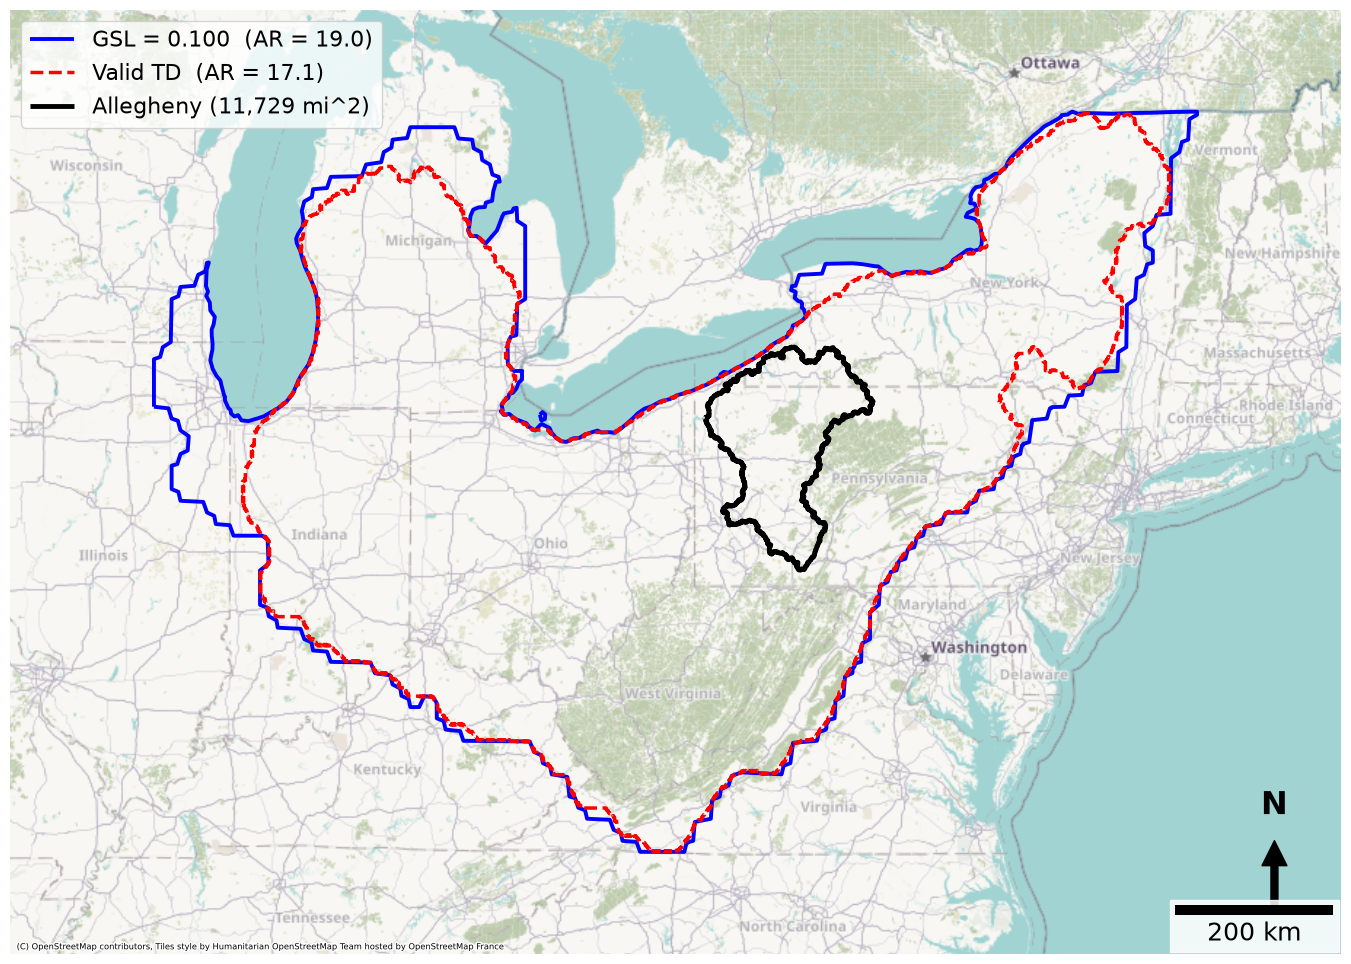

In [8]:
fig, ax = plt.subplots(figsize=(14, 12))

selected_ar = td_5070.area.iloc[0] / watershed_5070.area.iloc[0]
valid_ar    = td_valid_5070.area.iloc[0] / watershed_5070.area.iloc[0]
td_5070.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor='blue', linewidth=2.8,
    label=f'GSL = {SELECTED_GSL:.3f}  (AR = {selected_ar:.1f})',
)
td_valid_5070.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor='red', linewidth=2.5, linestyle='--',
    label=f'Valid TD  (AR = {valid_ar:.1f})',
)
watershed.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor='black', linewidth=3.5, linestyle='-',
    label=f'{WATERSHED_NAME} ({BASIN_AREA_MI2:,.0f} mi^2)',
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
xpad = (xmax - xmin) * 0.08
ypad = (ymax - ymin) * 0.08
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

cx.add_basemap(ax, crs=PLOT_CRS, source=OSM_BASEMAP_SOURCE, zoom=OSM_BASEMAP_ZOOM, alpha=0.85, attribution_size=6)
ax.set_axis_off()

center_lat_deg = watershed.to_crs(EQUAL_AREA_CRS).geometry.centroid.to_crs(GEOG_CRS).y.iloc[0]
ax.add_artist(ScaleBar(
    math.cos(math.radians(center_lat_deg)),
    units='m', location='lower right', box_alpha=0.85,
    rotation='horizontal-only',
    font_properties={'family': PLOT_FONT, 'size': PLOT_FONT_SIZE - 5},
))

# North arrow sitting on top of the scale bar (lower-right).
ax.annotate(
    '', xy=(0.95, 0.12), xytext=(0.95, 0.05),
    arrowprops=dict(facecolor='black', edgecolor='black',
                    width=5, headwidth=18, headlength=18),
    xycoords=ax.transAxes,
)
ax.text(0.95, 0.14, 'N', ha='center', va='bottom',
        fontsize=PLOT_FONT_SIZE, fontweight='bold', transform=ax.transAxes)

ax.legend(loc='upper left', frameon=True, fontsize=PLOT_FONT_SIZE - 7, ncol=1)
fig.tight_layout()
if not OUT_DIR.exists():
    OUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(
    OUT_DIR / 'selected_domain_map.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()

In [9]:
sel_ar = td_5070.area.iloc[0] / watershed_5070.area.iloc[0]
sel_tcap = AORC_YEARS * sel_ar
print(f'Selected TD area ratio = {sel_ar:.3f}')
print(f'Selected Tcap = {sel_tcap:.1f} year\n')

valid_ar = td_valid_5070.area.iloc[0] / watershed_5070.area.iloc[0]
valid_tcap = AORC_YEARS * valid_ar
print(f'Valid TD area ratio = {valid_ar:.3f}')
print(f'Valid Tcap = {valid_tcap:.1f} year\n')

reduction_factor = (1 - sel_tcap / valid_tcap)*100
print(f'Tcap Reduction factor = {reduction_factor:.3f}%')

Selected TD area ratio = 18.992
Selected Tcap = 873.6 year

Valid TD area ratio = 17.062
Valid Tcap = 784.9 year

Tcap Reduction factor = -11.306%


## Section 2 Max-pixel sanity flag and storms-per-year bar chart

Reports any storm whose max-pixel 72-hour precipitation exceeds `MAX_PIXEL_FLAG` (30 in by
default), which is at the assumed edge of physical plausibility for the CONUS 72-hour record and
typically indicates a single-pixel AORC artifact rather than a real meteorological signal.

In [10]:
flagged = storms[storms['max_in'] > MAX_PIXEL_FLAG].sort_values('max_in', ascending=False)
n_flag = len(flagged)
print(f'Storms with max-pixel > {MAX_PIXEL_FLAG:.0f} in: {n_flag}')
if n_flag:
    cols = ['storm_start_date', 'mean_in', 'min_in', 'max_in']
    print(flagged[cols].to_string(index=False))
else:
    print('All cataloged storms are within the plausibility envelope.')

Storms with max-pixel > 30 in: 0
All cataloged storms are within the plausibility envelope.


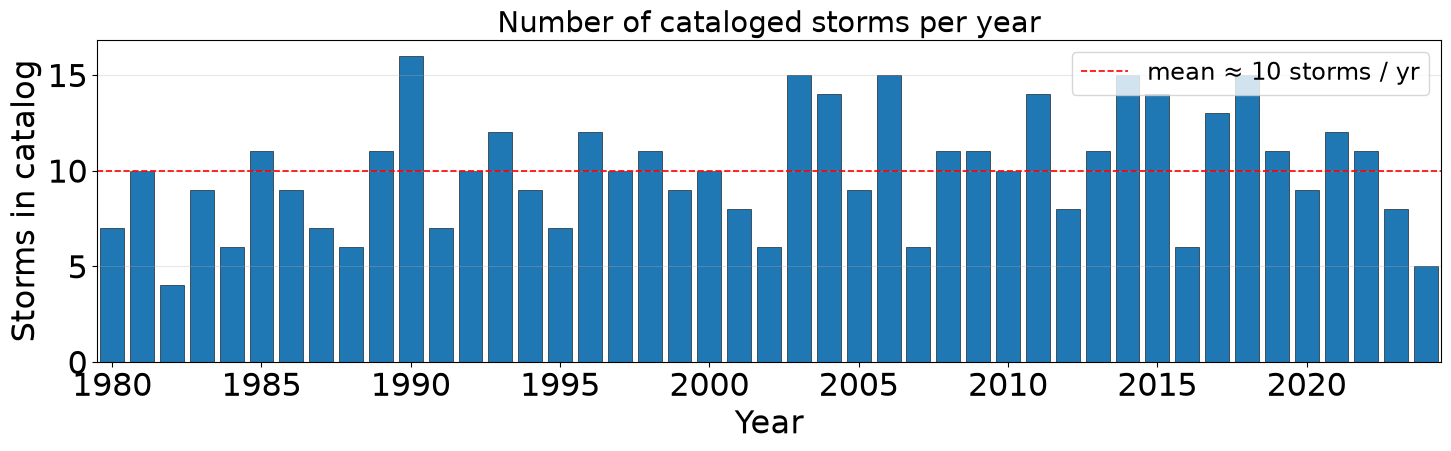

In [11]:
by_year = storms['year'].value_counts().sort_index()
yr_lo, yr_hi = int(by_year.index.min()), int(by_year.index.max())
years_all = pd.Series(0, index=range(yr_lo, yr_hi + 1)).astype(int)
years_all.update(by_year)

mean_per_year = round(years_all.mean())

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(years_all.index, years_all.values, color='#1f77b4', edgecolor='black', linewidth=0.4)
ax.axhline(mean_per_year, color='red', linestyle='--', linewidth=1.2,
            label=f'mean \u2248 {mean_per_year} storms / yr')
ax.set_xlabel('Year')
ax.set_ylabel('Storms in catalog')
ax.set_title('Number of cataloged storms per year', fontsize=PLOT_FONT_SIZE - 2)
ax.set_xlim(yr_lo - 0.5, yr_hi + 0.5)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', fontsize=PLOT_FONT_SIZE - 6)
fig.tight_layout()
fig.savefig(
    OUT_DIR / 'cataloged_storms_per_year.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()

## Section 3 Max-precip locations colored and sized by storm magnitude

Each marker is the wettest AORC pixel of one storm. Color encodes the max-pixel 72-hour
precipitation using Jenks Natural Breaks (k = 5). Marker size scales linearly with the same
value, and the size legend uses the same break values as the colorbar.

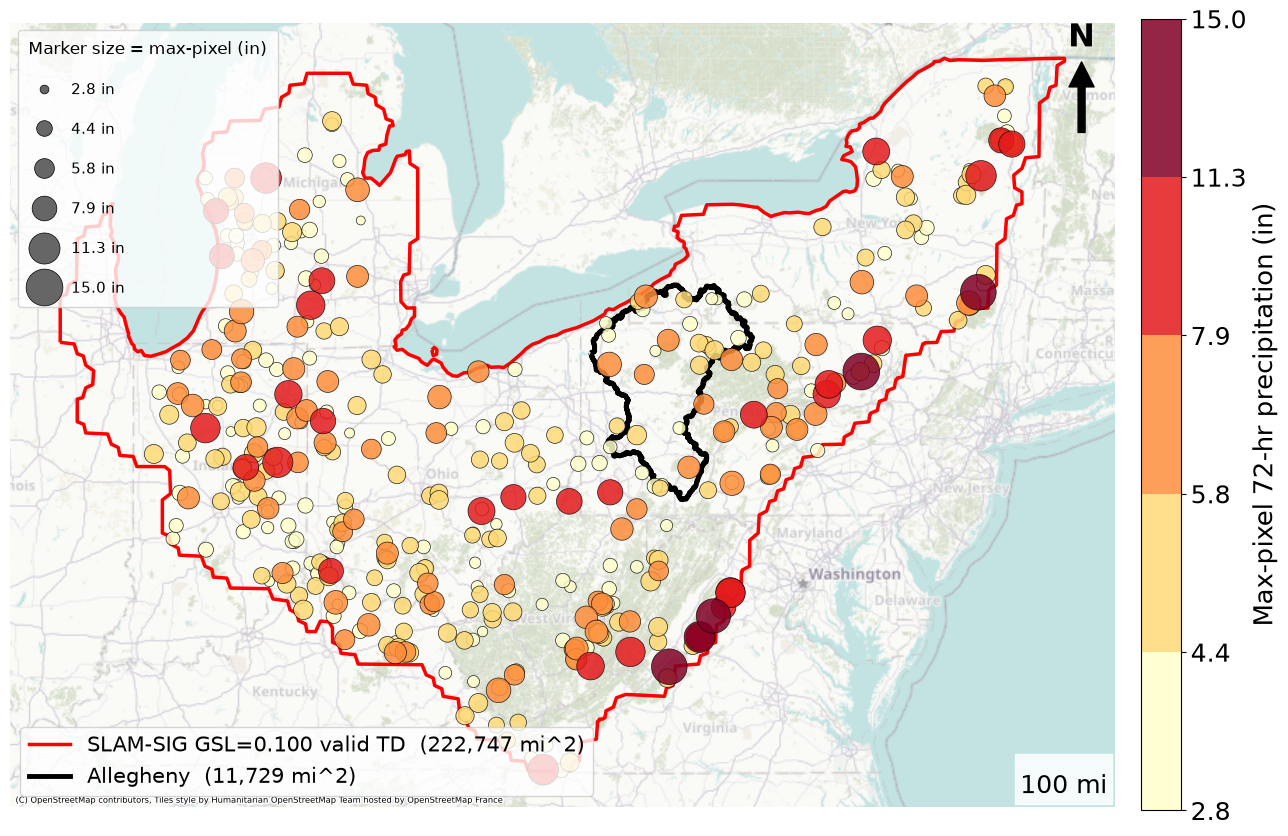

In [12]:
MIN_SIZE = 40
MAX_SIZE = 700

def magnitude_to_size(values, vmin, vmax):
    norm = (np.asarray(values) - vmin) / max(vmax - vmin, 1e-9)
    return MIN_SIZE + norm * (MAX_SIZE - MIN_SIZE)

vals = storms['max_in'].values
vmin, vmax = float(vals.min()), float(vals.max())

K = 5
breaks = list(mapclassify.NaturalBreaks(vals, k=K).bins.astype(float))
edges  = sorted(set([vmin] + breaks))
cmap   = mpl.colormaps['YlOrRd'].resampled(len(edges) - 1)
norm   = BoundaryNorm(edges, cmap.N)

sizes  = magnitude_to_size(vals, vmin, vmax)
storms_m = storms.to_crs(PLOT_CRS)
order    = np.argsort(vals)

fig, ax = plt.subplots(figsize=(14, 12))
td.to_crs(PLOT_CRS).boundary.plot(ax=ax, edgecolor='red', linewidth=2.5, zorder=2)
watershed.to_crs(PLOT_CRS).boundary.plot(ax=ax, edgecolor='black', linewidth=3.5, zorder=2)
sc = ax.scatter(storms_m.geometry.x.values[order],
                 storms_m.geometry.y.values[order],
                 c=vals[order], s=sizes[order], cmap=cmap, norm=norm,
                 edgecolor='black', linewidth=0.5, zorder=4, alpha=0.85)
basemap_axes(ax, td, pad_frac=0.05, basemap_alpha=0.55)

cbar = fig.colorbar(sc, ax=ax, ticks=edges, shrink=0.7, pad=0.02)
cbar.ax.set_yticklabels([f'{e:.1f}' for e in edges])
cbar.ax.tick_params(labelsize=PLOT_FONT_SIZE - 5)
cbar.set_label('Max-pixel 72-hr precipitation (in)', fontsize=PLOT_FONT_SIZE - 4)

size_handles = [Line2D([0], [0], marker='o', linestyle='',
                        markersize=math.sqrt(magnitude_to_size(v, vmin, vmax)),
                        markerfacecolor='#666', markeredgecolor='black',
                        markeredgewidth=0.5, label=f'{v:.1f} in')
                for v in edges]
size_legend = ax.legend(handles=size_handles,
                          title='Marker size = max-pixel (in)',
                          loc='upper left', frameon=True,
                          fontsize=PLOT_FONT_SIZE - 12,
                          title_fontsize=PLOT_FONT_SIZE - 11,
                          labelspacing=1.6, borderpad=0.7,
                          alignment='left')
ax.add_artist(size_legend)

boundary_handles = [
    Line2D([], [], color='red',   linewidth=2.5,
           label=f'{TD_NAME}  ({TD_AREA_MI2:,.0f} mi^2)'),
    Line2D([], [], color='black', linewidth=3.5,
           label=f'{WATERSHED_NAME}  ({BASIN_AREA_MI2:,.0f} mi^2)'),
]
ax.legend(handles=boundary_handles, loc='lower left', frameon=True,
           fontsize=PLOT_FONT_SIZE - 8)

fig.tight_layout()
fig.savefig(
    OUT_DIR / 'maximum_precipitation_locations.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()

## Section 4 Max-precip locations by season

Standard meteorological seasons (Northern Hemisphere):

- **Winter (DJF)**: December, January, February
- **Spring (MAM)**: March, April, May
- **Summer (JJA)**: June, July, August
- **Fall (SON)**: September, October, November

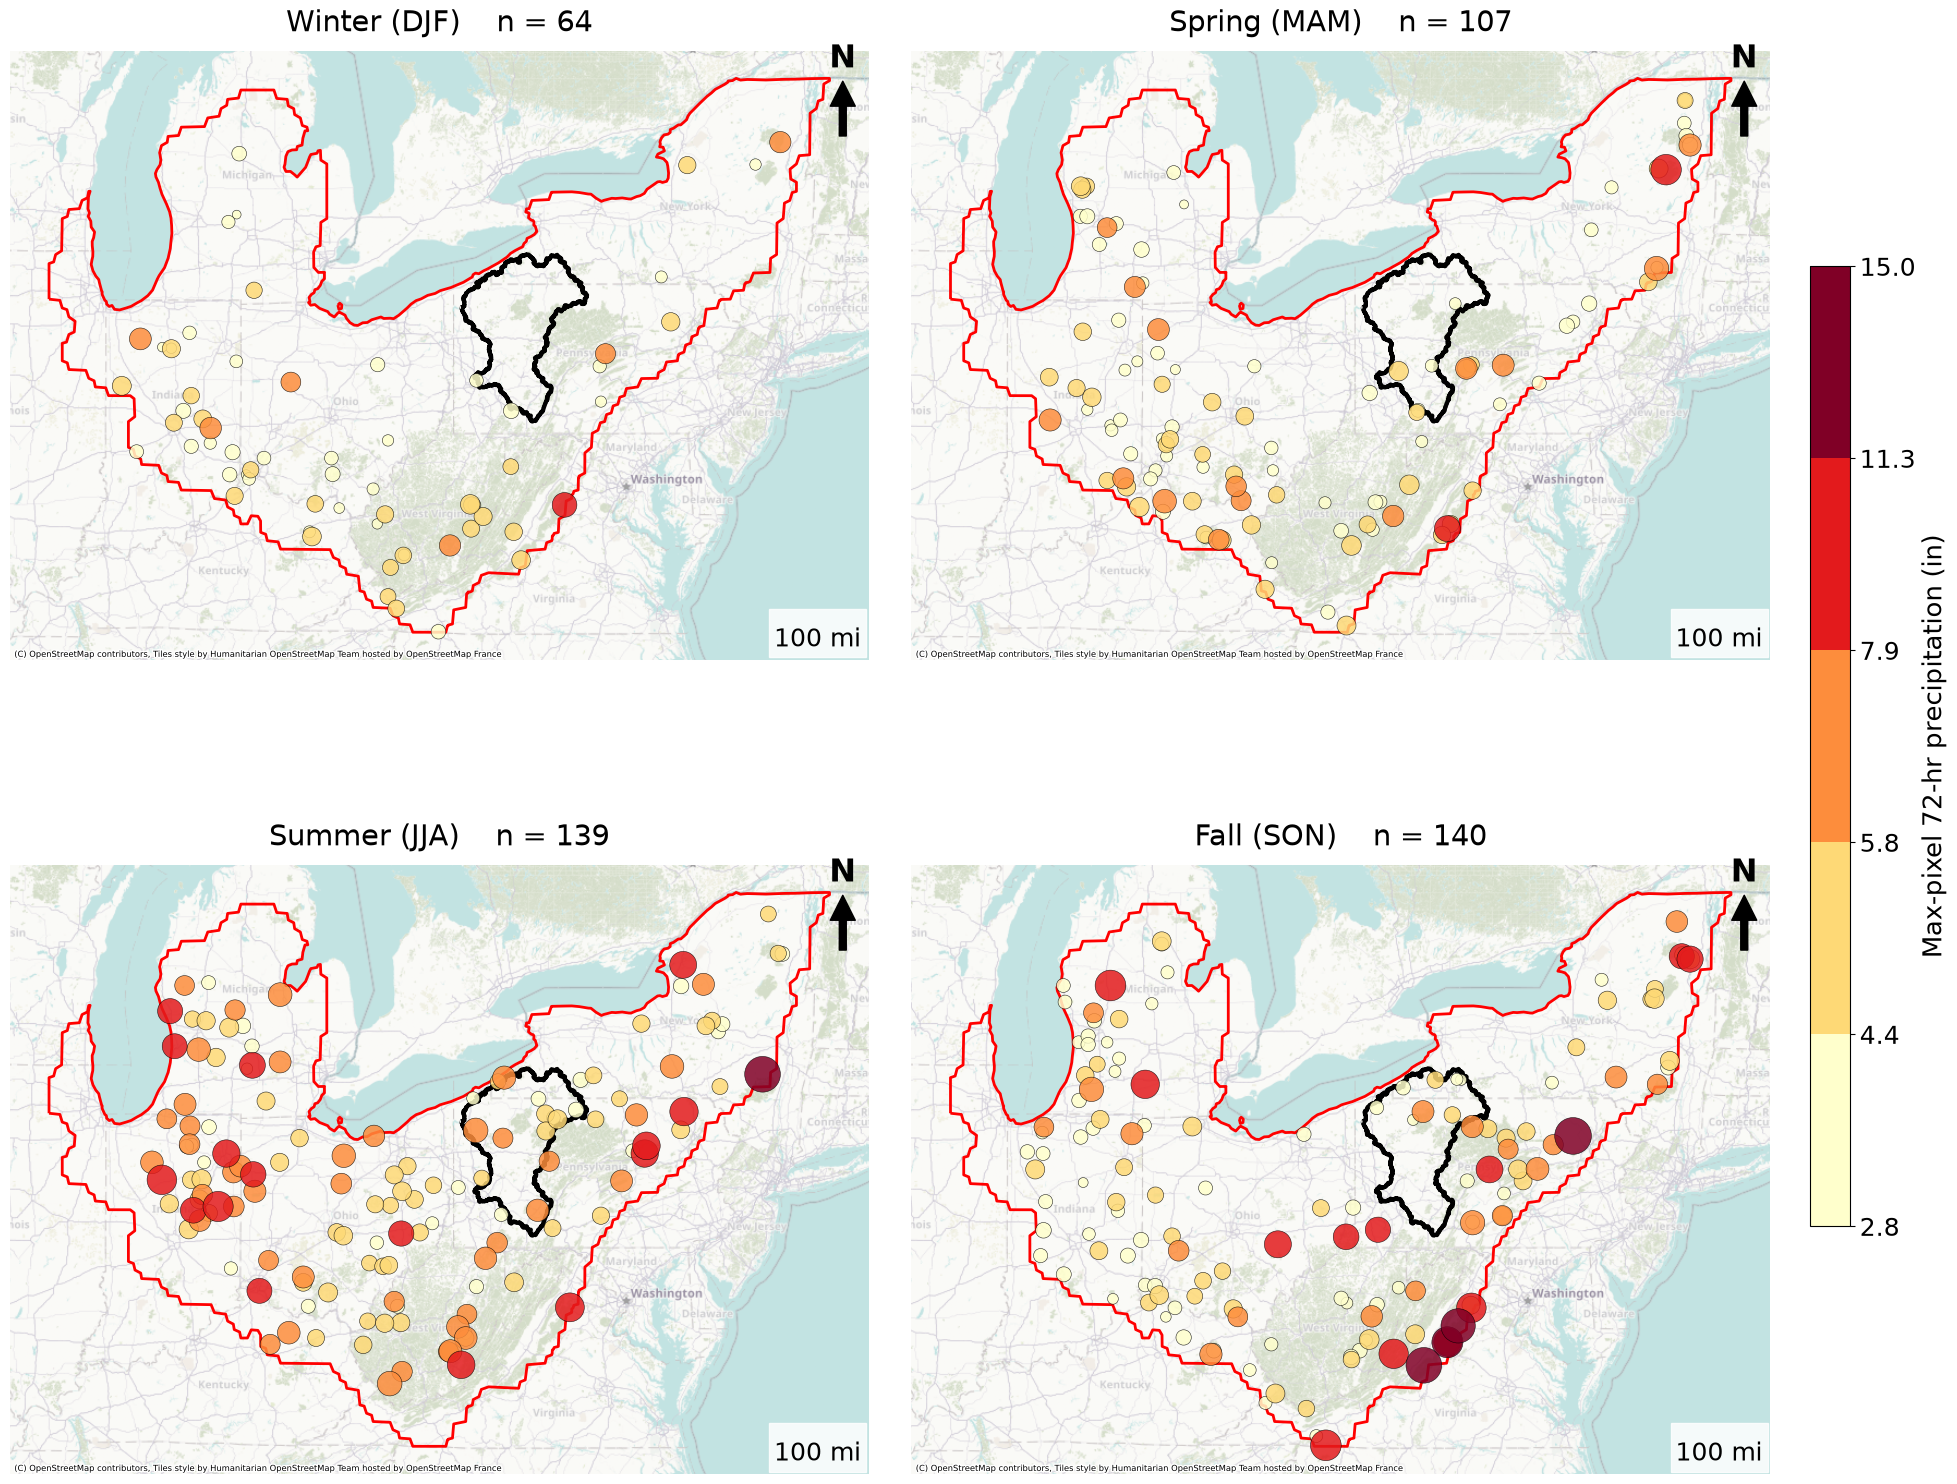

In [13]:
SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall',   10: 'Fall',  11: 'Fall'}
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Fall']
SEASON_LABEL = {'Winter': 'Winter (DJF)', 'Spring': 'Spring (MAM)',
                'Summer': 'Summer (JJA)', 'Fall':   'Fall (SON)'}

storms['season'] = storms['dt'].dt.month.map(SEASON_MAP)
season_counts    = storms['season'].value_counts().reindex(SEASON_ORDER).fillna(0).astype(int)

fig, axs = plt.subplots(2, 2, figsize=(20, 16), constrained_layout=False,
                         gridspec_kw={'hspace': 0.18, 'wspace': 0.05})
axs = axs.ravel()
for ax, season in zip(axs, SEASON_ORDER):
    sub = storms[storms['season'] == season]
    sub_m = sub.to_crs(PLOT_CRS)
    td.to_crs(PLOT_CRS).boundary.plot(ax=ax, edgecolor='red', linewidth=2.0, zorder=2)
    watershed.to_crs(PLOT_CRS).boundary.plot(ax=ax, edgecolor='black', linewidth=3.0, zorder=2)
    if len(sub):
        v = sub['max_in'].values
        s = magnitude_to_size(v, vmin, vmax)
        order_s = np.argsort(v)
        ax.scatter(sub_m.geometry.x.values[order_s],
                    sub_m.geometry.y.values[order_s],
                    c=v[order_s], s=s[order_s], cmap=cmap, norm=norm,
                    edgecolor='black', linewidth=0.4, zorder=4, alpha=0.85)
    basemap_axes(ax, td, pad_frac=0.05, basemap_alpha=0.55)
    ax.set_title(f'{SEASON_LABEL[season]}    n = {season_counts[season]}',
                  fontsize=PLOT_FONT_SIZE - 2, pad=14)

fig.subplots_adjust(left=0.02, right=0.90, top=0.96, bottom=0.02)
cax = fig.add_axes([0.92, 0.20, 0.02, 0.60])
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                    cax=cax, ticks=edges)
cbar.ax.set_yticklabels([f'{e:.1f}' for e in edges])
cbar.ax.tick_params(labelsize=PLOT_FONT_SIZE - 5)
cbar.set_label('Max-pixel 72-hr precipitation (in)', fontsize=PLOT_FONT_SIZE - 4)

fig.savefig(
    OUT_DIR / 'maximum_precipitation_locations_by_season.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()

## Section 5 Storm density heatmap

Hex-binned count of storm max-precip locations across the transposition domain. Cells with
more storms are darker. The basemap is a light monochrome gray (CartoDB Positron) so the
density colors stand out.

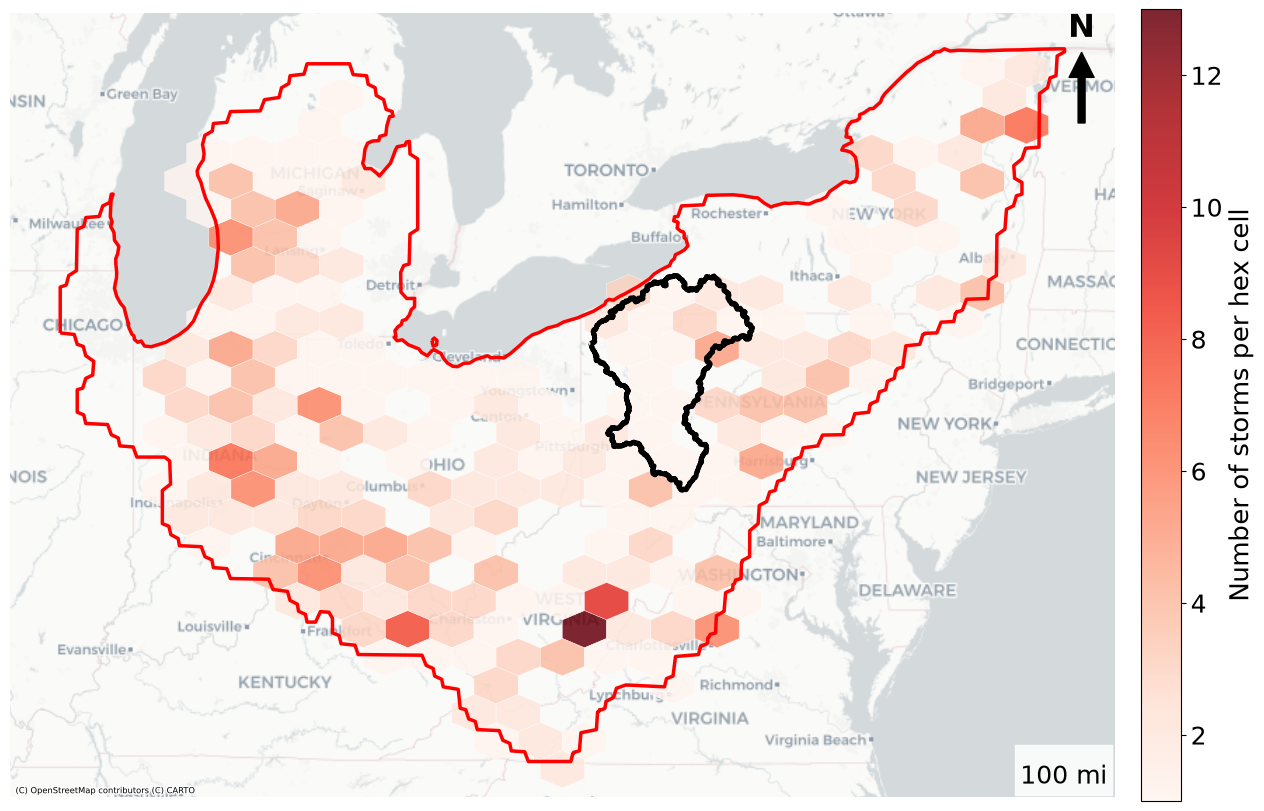

In [14]:
fig, ax = plt.subplots(figsize=(14, 12))
minx, miny, maxx, maxy = td.to_crs(PLOT_CRS).total_bounds
padx = (maxx - minx) * 0.05
pady = (maxy - miny) * 0.05

basemap_axes(ax, td, pad_frac=0.05,
              basemap_source=cx.providers.CartoDB.Positron, basemap_alpha=1.0,
              scale_bar=True, north_arrow=True)

hb = ax.hexbin(storms_m.geometry.x.values, storms_m.geometry.y.values,
                gridsize=25, mincnt=1, cmap='Reds',
                extent=(minx - padx, maxx + padx, miny - pady, maxy + pady),
                edgecolors='white', linewidths=0.3, alpha=0.85, zorder=3)

td.to_crs(PLOT_CRS).boundary.plot(ax=ax, edgecolor='red', linewidth=2.5, zorder=4)
watershed.to_crs(PLOT_CRS).boundary.plot(ax=ax, edgecolor='black', linewidth=3.5, zorder=4)

cbar = fig.colorbar(hb, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Number of storms per hex cell', fontsize=PLOT_FONT_SIZE - 4)
cbar.ax.tick_params(labelsize=PLOT_FONT_SIZE - 5)

fig.tight_layout()
fig.savefig(
    OUT_DIR / 'storm_location_density.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()

### Event calendar

Calendar scatter (day-of-year vs year) of every cataloged storm, colored and sized by
max-pixel 72-hr precipitation.

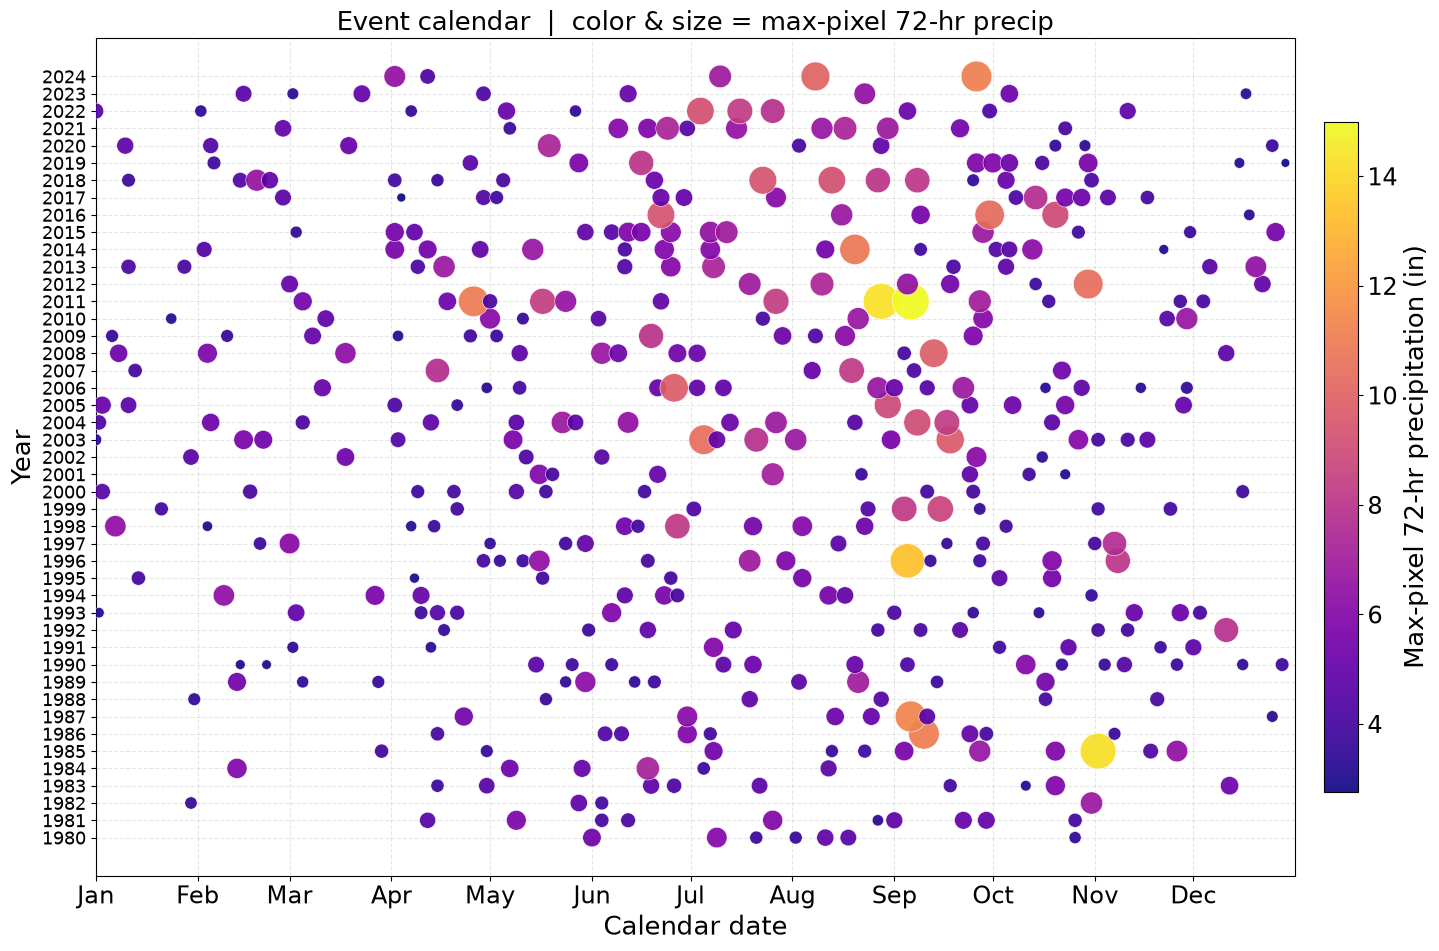

In [15]:
dates_df = pd.DataFrame({
    'date':         storms['dt'].values,
    'total_precip': storms['max_in'].values,
    'year':         storms['year'].values,
})
dates_df['day_of_year'] = pd.to_datetime(dates_df['date']).dt.dayofyear
dates_df['month']       = pd.to_datetime(dates_df['date']).dt.month
dates_df['month_name']  = pd.to_datetime(dates_df['date']).dt.strftime('%b')

dates_df = dates_df.sort_values('total_precip', ascending=False).reset_index(drop=True)
dates_df['overall_rank'] = dates_df.index + 1
dates_df = dates_df.sort_values(['year', 'date']).reset_index(drop=True)

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

precip_min = float(dates_df['total_precip'].min())
precip_max = float(dates_df['total_precip'].max())
scatter_norm = mpl.colors.Normalize(vmin=precip_min, vmax=precip_max)
scatter_cmap = mpl.colormaps['plasma']

fig, ax_cal = plt.subplots(1, 1, figsize=(16, 10))

sc = ax_cal.scatter(
    dates_df['day_of_year'],
    dates_df['year'],
    c=dates_df['total_precip'],
    s=magnitude_to_size(dates_df['total_precip'].values, precip_min, precip_max),
    cmap=scatter_cmap,
    norm=scatter_norm,
    edgecolors='white',
    linewidths=0.4,
    alpha=0.92,
    zorder=3,
)

cb = fig.colorbar(sc, ax=ax_cal, pad=0.02, shrink=0.8)
cb.set_label('Max-pixel 72-hr precipitation (in)', fontsize=PLOT_FONT_SIZE - 4)
cb.ax.tick_params(labelsize=PLOT_FONT_SIZE - 6)

all_years = sorted(dates_df['year'].unique())
ax_cal.set_yticks(all_years)
ax_cal.set_yticklabels(all_years, fontsize=PLOT_FONT_SIZE - 10)
ax_cal.set_xticks(month_starts)
ax_cal.set_xticklabels(month_labels, fontsize=PLOT_FONT_SIZE - 6)
ax_cal.set_xlim(1, 366)
ax_cal.set_xlabel('Calendar date', fontsize=PLOT_FONT_SIZE - 4)
ax_cal.set_ylabel('Year', fontsize=PLOT_FONT_SIZE - 4)
ax_cal.set_title('Event calendar  |  color & size = max-pixel 72-hr precip',
                 fontsize=PLOT_FONT_SIZE - 4)
ax_cal.grid(True, axis='x', linestyle='--', alpha=0.3)
ax_cal.grid(True, axis='y', linestyle='--', alpha=0.3)

fig.tight_layout()
fig.savefig(
    OUT_DIR / 'storms_calendar.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()


## Section 6: Precipitation distribution and ratio review

The first two histograms show the distributions of maximum grid-cell precipitation and watershed-mean precipitation for all catalog storms. The third histogram shows the maximum-to-mean precipitation ratio.

For each storm:

`maximum-to-mean ratio = maximum grid-cell precipitation / watershed-mean precipitation`

A high ratio means the wettest grid cell is much larger than the watershed mean. This can result from a localized storm or a single-pixel artifact. A low ratio means precipitation is spread more evenly across the watershed. This can result from a broad storm or a smoothed precipitation field.

The interquartile range, or IQR, provides the screening thresholds:

- Q1 is the 25th percentile.
- Q3 is the 75th percentile.
- IQR equals Q3 minus Q1.
- The lower fence equals Q1 minus 1.5 times the IQR.
- The upper fence equals Q3 plus 1.5 times the IQR.

The red lines on the ratio histogram show the lower and upper fences. Because the maximum and mean describe the same area, the ratio should be at least 1. If the lower fence is below 1, a valid ratio cannot fall below it.

Ratios outside the fences are review flags. They do not prove that a storm is invalid. Review the precipitation map, nearby observations, storm shape, and mass curve before removing or changing an event.

Q1: 1.64
Q3: 2.21
IQR: 0.58
Lower IQR fence: 0.77
Upper IQR fence: 3.08
Ratios below the lower fence: 0
Ratios above the upper fence: 19
Rows excluded because mean precipitation is zero or missing: 0
Saved figure: /workspaces/meteorology-tools/outputs/03_storm_catalog_maps/section6_precipitation_distribution_review.png


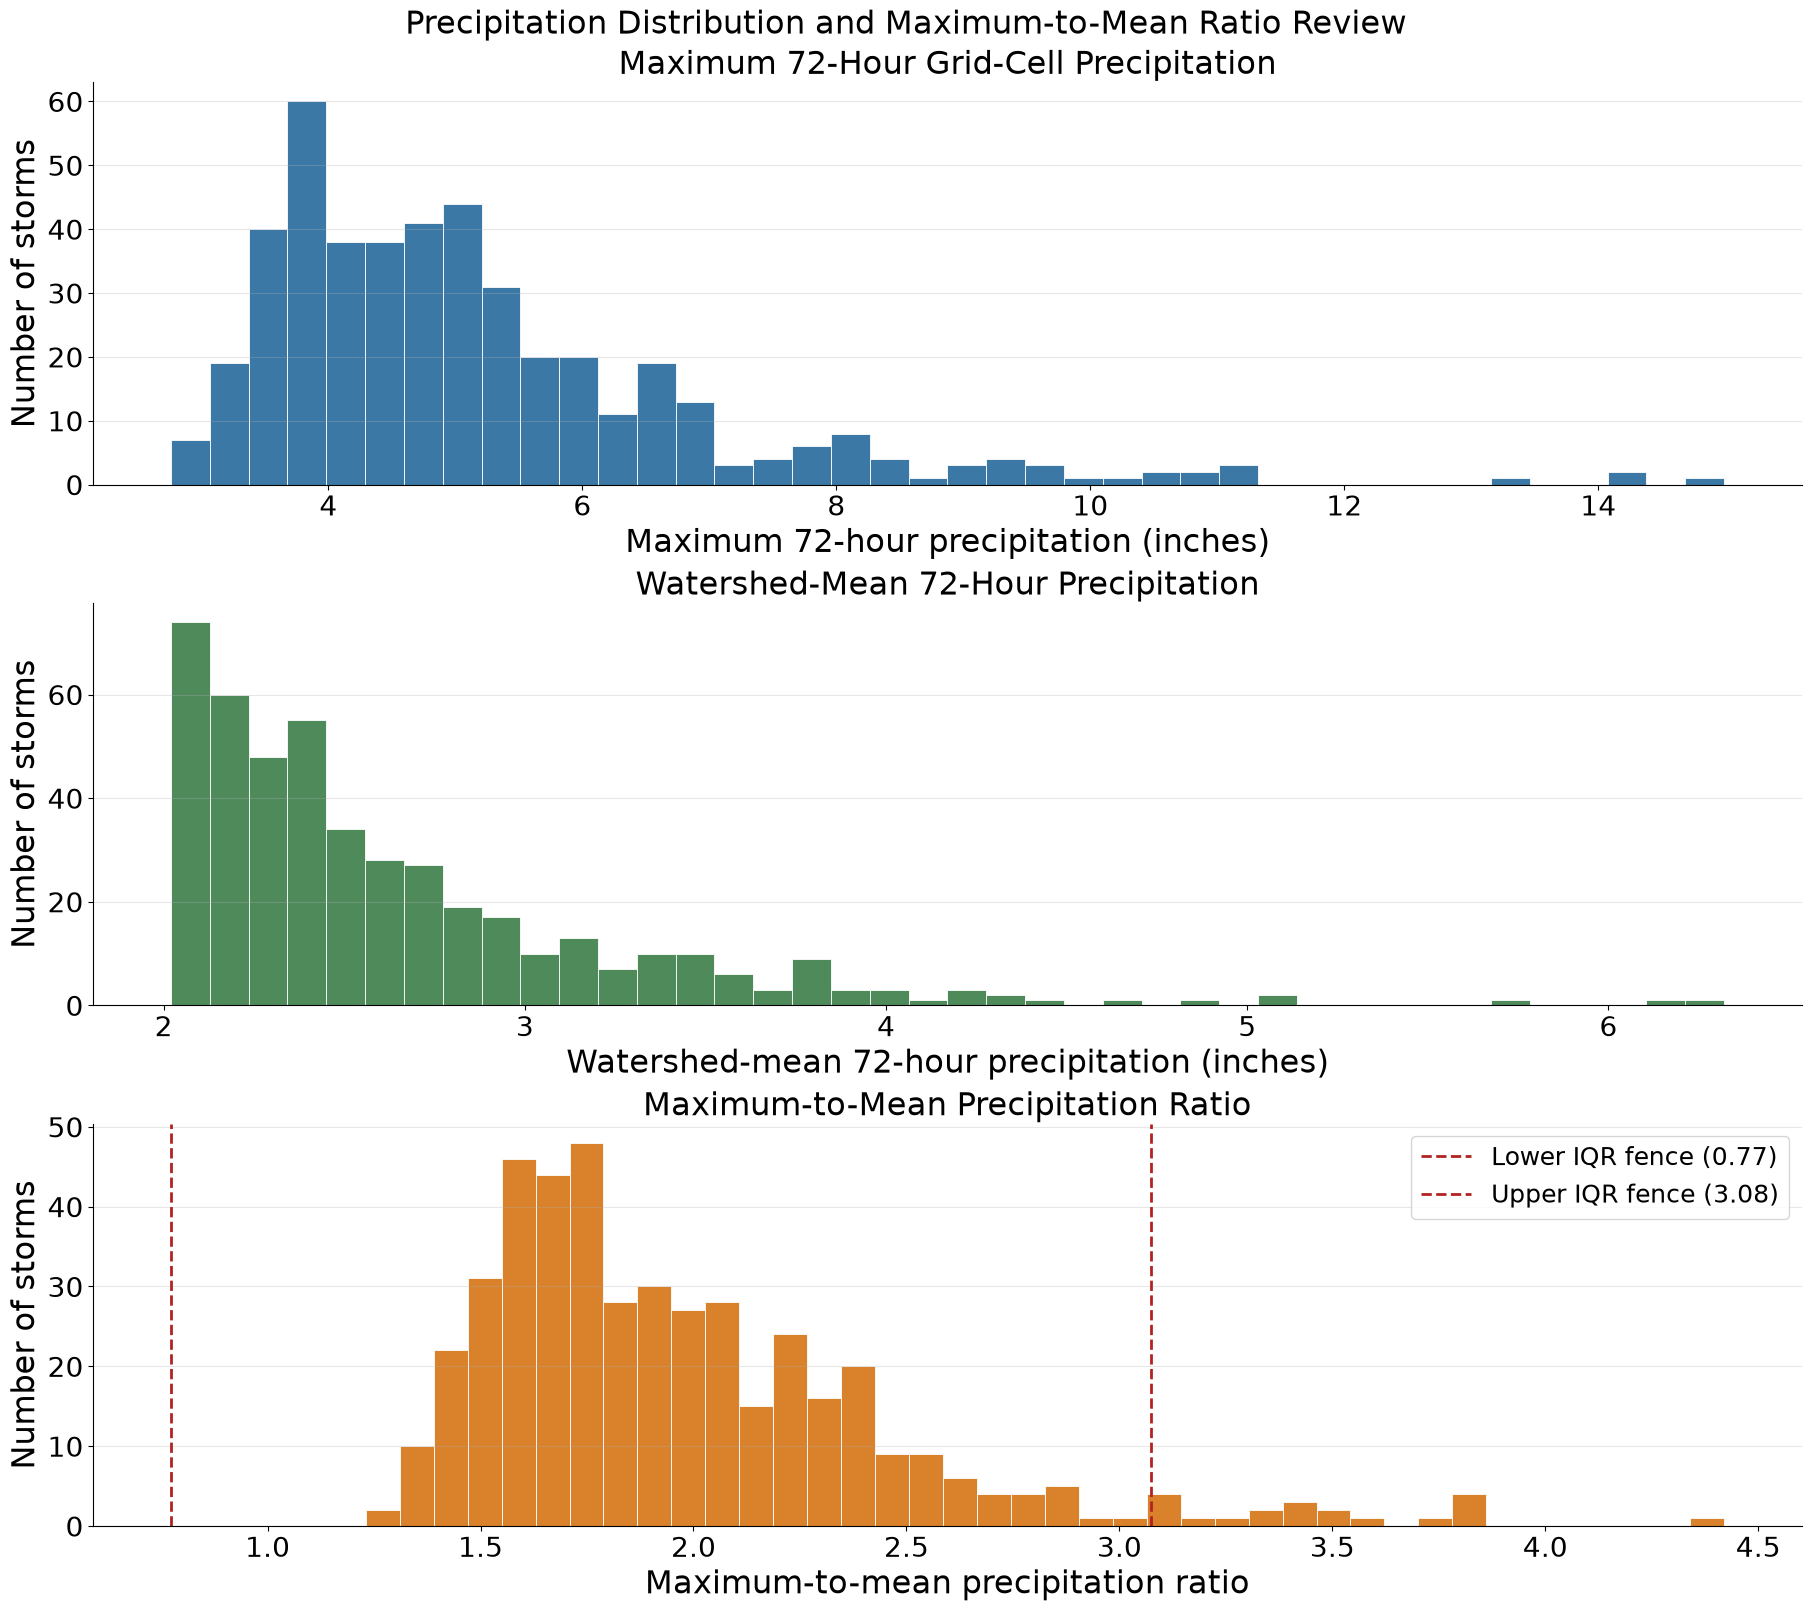

In [16]:
# Calculate the maximum-to-mean ratio and IQR review thresholds.
valid_mean = storms['mean_in'].notna() & (storms['mean_in'] > 0)
storms['ratio'] = np.nan
storms.loc[valid_mean, 'ratio'] = (
    storms.loc[valid_mean, 'max_in'] / storms.loc[valid_mean, 'mean_in']
)
ratio_values = storms['ratio'].dropna()

if ratio_values.empty:
    raise ValueError('No storms have a positive watershed-mean precipitation value.')

q1_ratio = ratio_values.quantile(0.25)
q3_ratio = ratio_values.quantile(0.75)
iqr_ratio = q3_ratio - q1_ratio
ratio_lo = q1_ratio - 1.5 * iqr_ratio
ratio_hi = q3_ratio + 1.5 * iqr_ratio

flag_ratio_high = storms['ratio'].notna() & (storms['ratio'] > ratio_hi)
flag_ratio_low = storms['ratio'].notna() & (storms['ratio'] < ratio_lo)

print(f'Q1: {q1_ratio:.2f}')
print(f'Q3: {q3_ratio:.2f}')
print(f'IQR: {iqr_ratio:.2f}')
print(f'Lower IQR fence: {ratio_lo:.2f}')
print(f'Upper IQR fence: {ratio_hi:.2f}')
print(f'Ratios below the lower fence: {flag_ratio_low.sum()}')
print(f'Ratios above the upper fence: {flag_ratio_high.sum()}')
print(f'Rows excluded because mean precipitation is zero or missing: {(~valid_mean).sum()}')

fig, axes = plt.subplots(3, 1, figsize=(18, 16), constrained_layout=True)

# Maximum precipitation distribution
ax = axes[0]
ax.hist(
    storms['max_in'].dropna(),
    bins=40,
    color='#3B78A6',
    edgecolor='white',
    linewidth=0.6,
)
ax.set_xlabel('Maximum 72-hour precipitation (inches)')
ax.set_ylabel('Number of storms')
ax.set_title(
    'Maximum 72-Hour Grid-Cell Precipitation',
    fontsize=PLOT_FONT_SIZE,
    fontweight='normal',
)

# Watershed-mean precipitation distribution
ax = axes[1]
ax.hist(
    storms['mean_in'].dropna(),
    bins=40,
    color='#4F8A5B',
    edgecolor='white',
    linewidth=0.6,
)
ax.set_xlabel('Watershed-mean 72-hour precipitation (inches)')
ax.set_ylabel('Number of storms')
ax.set_title(
    'Watershed-Mean 72-Hour Precipitation',
    fontsize=PLOT_FONT_SIZE,
    fontweight='normal',
)

# Maximum-to-mean ratio distribution
ax = axes[2]
ax.hist(
    ratio_values,
    bins=40,
    color='#D9822B',
    edgecolor='white',
    linewidth=0.6,
)
ax.axvline(
    ratio_lo,
    color='#B22222',
    linestyle='--',
    linewidth=2,
    label=f'Lower IQR fence ({ratio_lo:.2f})',
)
ax.axvline(
    ratio_hi,
    color='#B22222',
    linestyle='--',
    linewidth=2,
    label=f'Upper IQR fence ({ratio_hi:.2f})',
)
ax.set_xlabel('Maximum-to-mean precipitation ratio')
ax.set_ylabel('Number of storms')
ax.set_title(
    'Maximum-to-Mean Precipitation Ratio',
    fontsize=PLOT_FONT_SIZE,
    fontweight='normal',
)
ax.legend(fontsize=PLOT_FONT_SIZE - 5)

for ax in axes:
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=PLOT_FONT_SIZE - 3)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

fig.suptitle(
    'Precipitation Distribution and Maximum-to-Mean Ratio Review',
    fontsize=PLOT_FONT_SIZE,
    fontweight='normal',
)
distribution_figure_path = OUT_DIR / 'section6_precipitation_distribution_review.png'
fig.savefig(
    distribution_figure_path,
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
print(f'Saved figure: {distribution_figure_path}')
plt.show()

### Storms outside the ratio fences

The next cell creates two review tables. The table above the upper fence is sorted from the largest ratio to the smallest. The table below the lower fence is sorted from the smallest ratio to the largest.

These storms should be reviewed first because their spatial concentration differs from most catalog events. A row in either table is not an automatic rejection. Check the precipitation map, storm extent, nearby observations, and mass curve before deciding whether the event is valid.

The combined review table is also saved as a CSV file in the notebook output folder.

In [17]:
# Create and print tables for storms outside the IQR fences.
review_fields = ['storm_start_date', 'mean_in', 'max_in', 'ratio']
review_names = {
    'storm_start_date': 'Storm start date',
    'mean_in': 'Watershed mean precipitation (inches)',
    'max_in': 'Maximum precipitation (inches)',
    'ratio': 'Maximum-to-mean ratio',
}

flagged_ratio_high = (
    storms.loc[flag_ratio_high, review_fields]
    .copy()
    .sort_values('ratio', ascending=False)
    .rename(columns=review_names)
)
flagged_ratio_low = (
    storms.loc[flag_ratio_low, review_fields]
    .copy()
    .sort_values('ratio', ascending=True)
    .rename(columns=review_names)
)

high_ratio_review = flagged_ratio_high.copy()
high_ratio_review.insert(0, 'Review flag', 'Above upper IQR fence')
low_ratio_review = flagged_ratio_low.copy()
low_ratio_review.insert(0, 'Review flag', 'Below lower IQR fence')

ratio_review = pd.concat(
    [high_ratio_review, low_ratio_review],
    ignore_index=True,
)
ratio_review_path = OUT_DIR / 'section6_ratio_review.csv'
ratio_review.to_csv(ratio_review_path, index=False)

print(f'Ratios above the upper IQR fence of {ratio_hi:.2f}')
if flagged_ratio_high.empty:
    print('No storms fall above the upper fence.')
else:
    print(flagged_ratio_high.to_string(index=False))

print(f'\nRatios below the lower IQR fence of {ratio_lo:.2f}')
if flagged_ratio_low.empty:
    print('No storms fall below the lower fence.')
else:
    print(flagged_ratio_low.to_string(index=False))

print(f'\nSaved review table: {ratio_review_path}')

Ratios above the upper IQR fence of 3.08
         Storm start date  Watershed mean precipitation (inches)  Maximum precipitation (inches)  Maximum-to-mean ratio
1987-09-06 00:00:00+00:00                                   2.55                           11.27               4.419608
1999-09-04 00:00:00+00:00                                   2.14                            8.25               3.855140
2022-07-16 00:00:00+00:00                                   2.18                            8.37               3.839450
2018-08-13 00:00:00+00:00                                   2.44                            9.24               3.786885
2009-06-19 00:00:00+00:00                                   2.11                            7.99               3.786730
2011-08-28 00:00:00+00:00                                   3.78                           14.28               3.777778
2016-09-29 00:00:00+00:00                                   2.86                           10.34               3.615385

### Maximum precipitation by season and decade

The next cell assigns each storm to a decade with:

`storms['decade'] = (storms['year'] // 10 * 10).astype(str) + 's'`

Integer division by 10 removes the final digit from the year. Multiplying by 10 returns the first year of that decade. Converting the result to text and adding `s` creates the display label. For example, 1997 becomes 1990s.

The boxplots compare maximum 72-hour precipitation among seasons and decades:

- Each box covers the middle 50 percent of values from Q1 to Q3.
- The line inside a box is the median.
- The whiskers extend to values within 1.5 times the IQR.
- Points beyond the whiskers are potential outliers.
- The sample count for each group is shown below its label.

Groups with few storms may have unstable summaries. The plots describe the catalog distributions and do not establish a trend.

Saved figure: /workspaces/meteorology-tools/outputs/03_storm_catalog_maps/section6_maximum_precipitation_by_season_and_decade.png


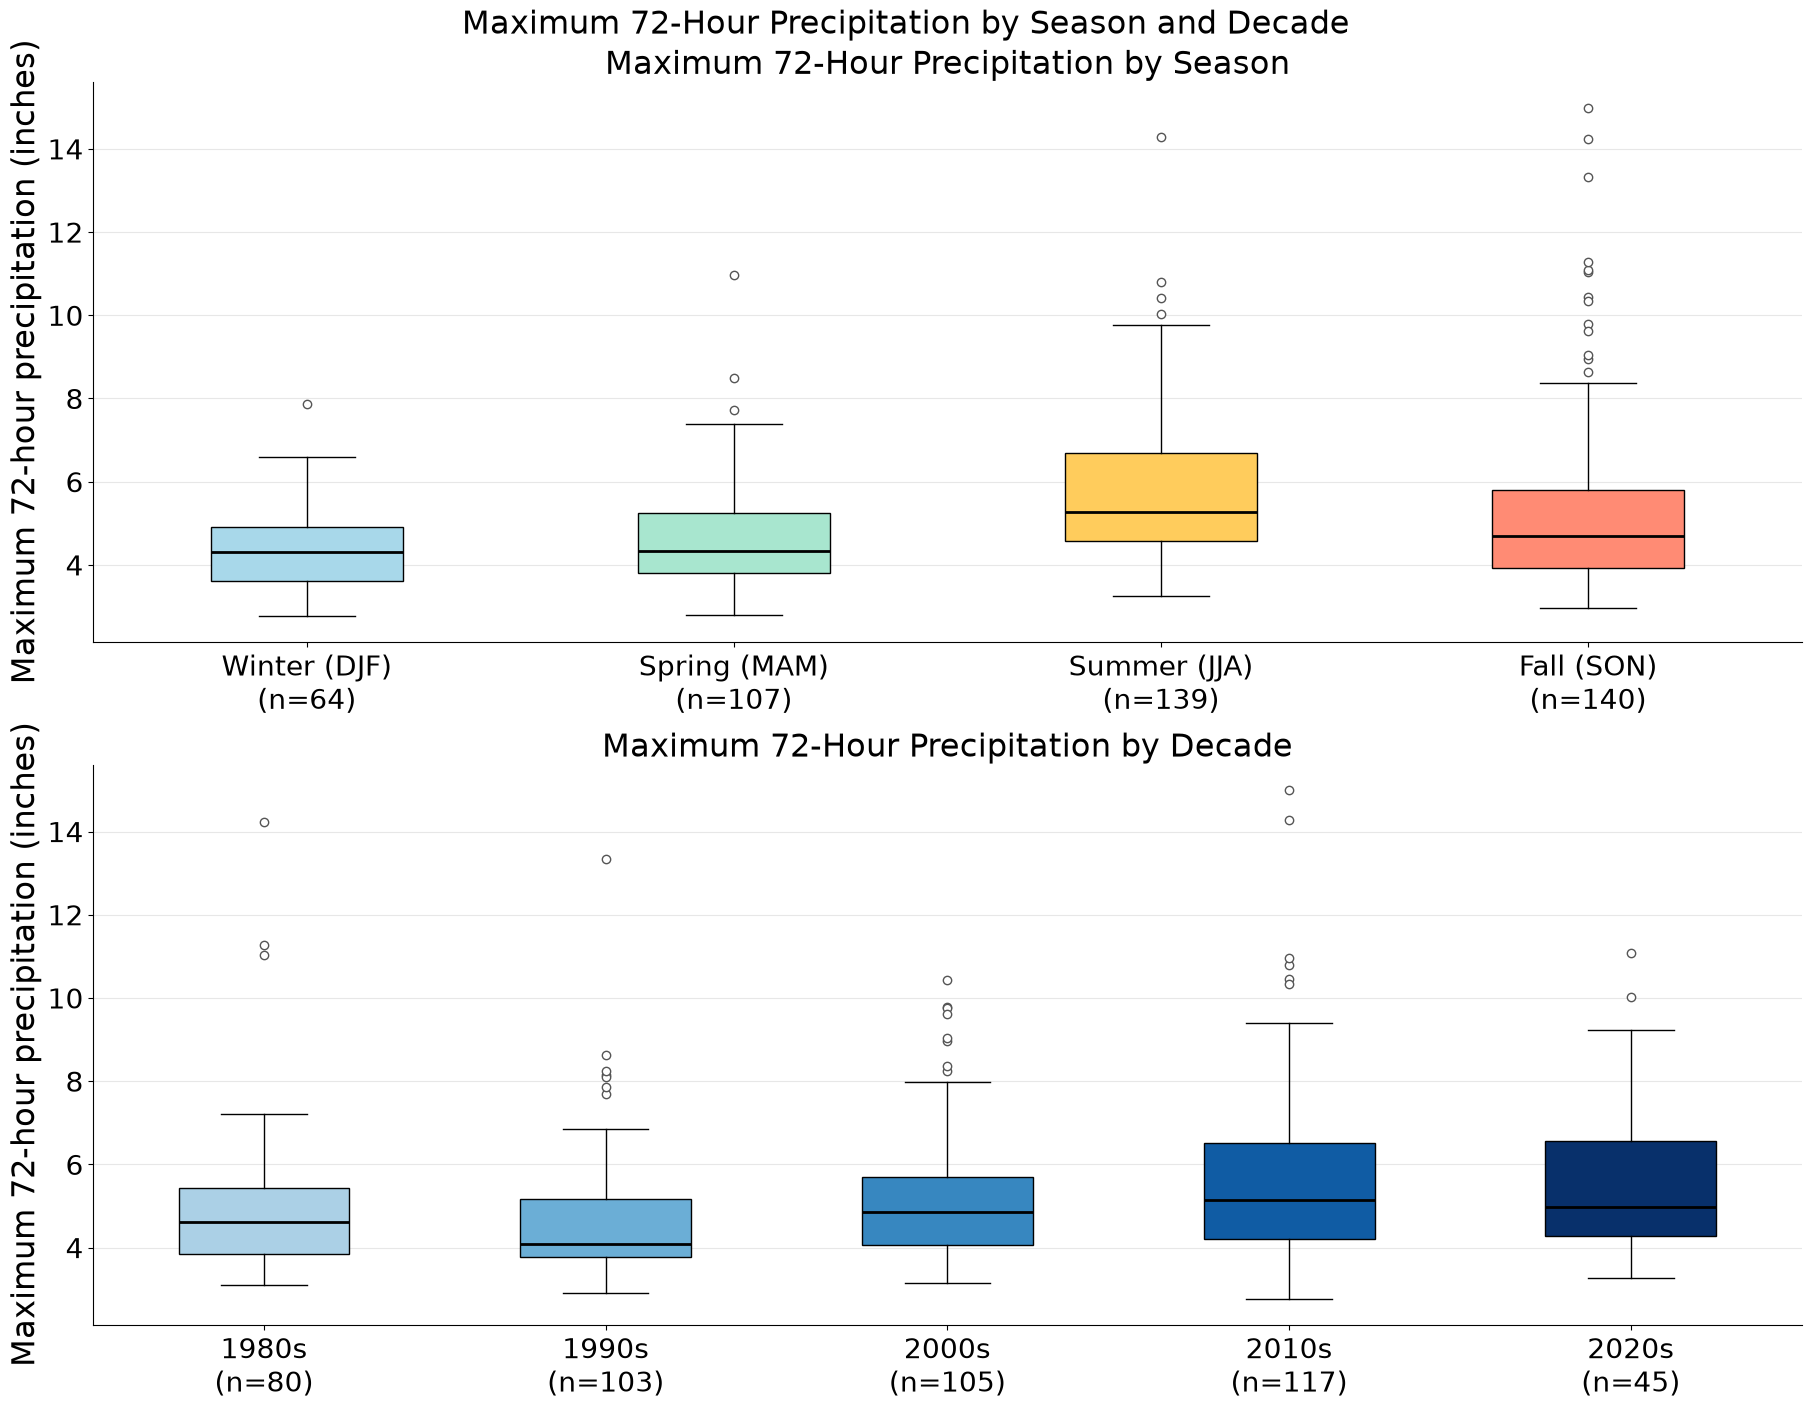

In [18]:
storms['decade'] = (storms['year'] // 10 * 10).astype(str) + 's'
decade_order = sorted(storms['decade'].dropna().unique())

season_data = [
    storms.loc[storms['season'] == season, 'max_in'].dropna().values
    for season in SEASON_ORDER
]
season_counts = [
    int((storms['season'] == season).sum())
    for season in SEASON_ORDER
]
season_labels = [
    f'{SEASON_LABEL[season]}\n(n={count})'
    for season, count in zip(SEASON_ORDER, season_counts)
]

decade_data = [
    storms.loc[storms['decade'] == decade, 'max_in'].dropna().values
    for decade in decade_order
]
decade_counts = [
    int((storms['decade'] == decade).sum())
    for decade in decade_order
]
decade_labels = [
    f'{decade}\n(n={count})'
    for decade, count in zip(decade_order, decade_counts)
]

fig, (ax_s, ax_d) = plt.subplots(
    2,
    1,
    figsize=(18, 14),
    constrained_layout=True,
)

# Seasonal comparison
season_palette = ['#A8D8EA', '#A8E6CF', '#FFCC5C', '#FF8B74']
bp1 = ax_s.boxplot(
    season_data,
    tick_labels=season_labels,
    patch_artist=True,
    notch=False,
    medianprops={'color': 'black', 'linewidth': 2},
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': '#555555',
        'markersize': 6,
    },
)
for patch, color in zip(bp1['boxes'], season_palette):
    patch.set_facecolor(color)
ax_s.set_ylabel('Maximum 72-hour precipitation (inches)')
ax_s.set_title(
    'Maximum 72-Hour Precipitation by Season',
    fontsize=PLOT_FONT_SIZE,
    fontweight='normal',
)

# Decadal comparison
dec_cmap = mpl.colormaps['Blues'].resampled(len(decade_order) + 2)
bp2 = ax_d.boxplot(
    decade_data,
    tick_labels=decade_labels,
    patch_artist=True,
    notch=False,
    medianprops={'color': 'black', 'linewidth': 2},
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': '#555555',
        'markersize': 6,
    },
)
for index, patch in enumerate(bp2['boxes']):
    patch.set_facecolor(dec_cmap((index + 2) / (len(decade_order) + 2)))
ax_d.set_ylabel('Maximum 72-hour precipitation (inches)')
ax_d.set_title(
    'Maximum 72-Hour Precipitation by Decade',
    fontsize=PLOT_FONT_SIZE,
    fontweight='normal',
)

for ax in (ax_s, ax_d):
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=PLOT_FONT_SIZE - 3)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

fig.suptitle(
    'Maximum 72-Hour Precipitation by Season and Decade',
    fontsize=PLOT_FONT_SIZE,
    fontweight='normal',
)
boxplot_figure_path = OUT_DIR / 'section6_maximum_precipitation_by_season_and_decade.png'
fig.savefig(
    boxplot_figure_path,
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)
print(f'Saved figure: {boxplot_figure_path}')
plt.show()